# Pipelines 

We can stack various pre-processing methods and the machine learning model in a pipeline

For example, if all features were nominal (categorical without order), we could stack a `OneHotEncoder()` followed by a classifier, e.g. `LogisticRegression()`

Conversion of the features happens under the hood

In [18]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [19]:
X = np.array([
    ['sunny', 'summer'],
    ['rainy', 'summer'],
    ['rainy', 'fall'],
    ['cloudy', 'winter'],
    ['very rainy', 'spring'],
    ['sunny', 'winter'],
    ['partially cloudy', 'spring']
])

y = np.array([
    'T-shirt',
    'T-shirt',
    'Coat',
    'Coat',
    'Coat',
    'Coat',
    'T-shirt'
])

In [20]:
X.shape

(7, 2)

In [21]:
y.shape

(7,)

In [23]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

model = make_pipeline(OneHotEncoder(),
                      LogisticRegression())

In [24]:
model.fit(X, y)

,steps,"[('onehotencoder', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None


In [25]:
model.score(X, y)

1.0

In [26]:
model.predict([['cloudy', 'spring']])

array(['Coat'], dtype='<U7')

We can setup the same pipeline with an `OrdinalEncoder()`. However, these features do not have order (so we should not!)

In [29]:
model = make_pipeline(OrdinalEncoder(),
                      LogisticRegression())
model.fit(X, y)
model.score(X, y)

0.5714285714285714

In [30]:
model.predict([['cloudy', 'spring']])

array(['T-shirt'], dtype='<U7')

We get a different answer. Note that Decision Tree methods might be less susceptible to this

## Practice encoding and pipeline with a decision tree

In [31]:
X = np.array([
    ['sunny', 'summer'],
    ['rainy', 'summer'],
    ['rainy', 'fall'],
    ['cloudy', 'winter'],
    ['very rainy', 'spring'],
    ['sunny', 'winter'],
    ['partially cloudy', 'spring']
])

y = np.array([
    'T-shirt',
    'T-shirt',
    'Coat',
    'Coat',
    'Coat',
    'Coat',
    'T-shirt'
])

### Question: Can you build and visualize a decision tree using this data and a pipeline?

In [32]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier

model = make_pipeline(OneHotEncoder(),
                      DecisionTreeClassifier())

In [33]:
# Fit model
model.fit(X, y)

,steps,"[('onehotencoder', ...), ('decisiontreeclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None


In [34]:
# Get training score
model.score(X, y)

1.0

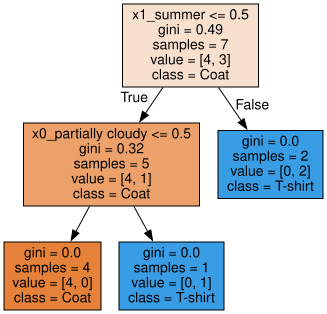

In [35]:
# export tree as graphviz object

from sklearn.tree import export_graphviz
export_graphviz(model.named_steps['decisiontreeclassifier'], 
                feature_names=model.named_steps['onehotencoder'].get_feature_names_out(),
                class_names=np.unique(y),
                out_file="weather-tree.dot", impurity=True, filled=True)

import graphviz

with open("weather-tree.dot") as f:
    dot_graph = f.read()
display(graphviz.Source(dot_graph))

gini impurity is $\sum_{i=classes} p_{i}*(1-p_{i})$

with  
Number of samples=5  
class 0 (Coat): 4  
class 1 (T-shirt): 1  

$p_{coat} = 4/5$  

$p_{shirt} = 1/5$

In [17]:
# calculate gini impurity
gini = 4/5*(1-4/5) + 1/5*(1-1/5)
gini

0.32